# Malaria Symptom Triage Helper MVP

In [69]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Nigerian_Malaria_Symptoms_Survey_Synthetic.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,respondent_id,age,gender,state,fever,high_fever,headache,chills,vomiting,duration,malaria_test,diagnosis
0,NGM10001,42.0,Male,Kano,Yes,No,Yes,Yes,Yes,6-7 days,Not Done,Malaria
1,NGM10002,12.0,Male,FCT,No,No,Yes,No,Yes,1-2 days,Not Done,No Malaria
2,NGM10003,75.0,Male,Enugu,Yes,No,Yes,Yes,Yes,3-5 days,Negative,Malaria
3,NGM10004,40.0,Male,Oyo,Yes,Yes,No,Yes,Yes,1-2 days,Not Done,No Malaria
4,NGM10005,69.0,Male,FCT,No,No,No,No,No,6-7 days,Negative,No Malaria


## 1. Data Loading and Initial Inspection

In [70]:
print('DataFrame Info:')
df.info()

print('\nDataFrame Description:')
display(df.describe(include='all'))

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   respondent_id  2040 non-null   object 
 1   age            2002 non-null   float64
 2   gender         2040 non-null   object 
 3   state          2040 non-null   object 
 4   fever          2040 non-null   object 
 5   high_fever     2040 non-null   object 
 6   headache       2040 non-null   object 
 7   chills         2040 non-null   object 
 8   vomiting       2040 non-null   object 
 9   duration       1558 non-null   object 
 10  malaria_test   2040 non-null   object 
 11  diagnosis      2040 non-null   object 
dtypes: float64(1), object(11)
memory usage: 191.4+ KB

DataFrame Description:


,respondent_id,age,gender,state,fever,high_fever,headache,chills,vomiting,duration,malaria_test,diagnosis
count,2040,2002.000000,2040,2040,2040,2040,2040,2040,2040,1558,2040,2040
unique,2000,NaN,3,11,2,2,2,2,2,3,3,2
top,NGM10859,NaN,Male,Rivers,No,No,Yes,Yes,No,6-7 days,Not Done,No Malaria
freq,2,NaN,1020,215,1029,1508,1021,1045,1033,520,701,1703
mean,NaN,38.296703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,21.602096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Preprocessing

In [71]:
print('Missing values before imputation:')
display(df.isnull().sum())

# Impute missing 'age' values with the median
df['age'] = df['age'].fillna(df['age'].median())

# Impute missing 'duration' values with the mode
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

print('\nMissing values after imputation:')
display(df.isnull().sum())

Missing values before imputation:


,0
respondent_id,0
age,38
gender,0
state,0
fever,0
high_fever,0
headache,0
chills,0
vomiting,0
duration,482



Missing values after imputation:


,0
respondent_id,0
age,0
gender,0
state,0
fever,0
high_fever,0
headache,0
chills,0
vomiting,0
duration,0


### 2.1 Handling Missing Values

In [72]:
print('Unique values for categorical columns:')
for col in df.select_dtypes(include='object').columns:
    print(f"\nColumn '{col}': {df[col].unique()}")

Unique values for categorical columns:

Column 'respondent_id': ['NGM10001' 'NGM10002' 'NGM10003' ... 'NGM11998' 'NGM11999' 'NGM12000']

Column 'gender': ['Male' 'Female' 'Mle']

Column 'state': ['Kano' 'FCT' 'Enugu' 'Oyo' 'Rivers' 'Borno' 'Sokoto' 'Katsina' 'Lagos'
 'Kaduna' 'Kno']

Column 'fever': ['Yes' 'No']

Column 'high_fever': ['No' 'Yes']

Column 'headache': ['Yes' 'No']

Column 'chills': ['Yes' 'No']

Column 'vomiting': ['Yes' 'No']

Column 'duration': ['6-7 days' '1-2 days' '3-5 days']

Column 'malaria_test': ['Not Done' 'Negative' 'Positive']

Column 'diagnosis': ['Malaria' 'No Malaria']


### 2.2 Categorical Feature Analysis and Preprocessing

In [73]:
import pandas as pd

# The dataset was loaded and initial missing values were handled in previous cells.
# This cell continues the preprocessing from the current state of the DataFrame (df).

# 1. Drop 'respondent_id' and 'malaria_test' columns as they are not used for training
# Use errors='ignore' and check for column existence to prevent KeyError if columns are already dropped
columns_to_drop = ['respondent_id', 'malaria_test']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1, errors='ignore')

# 2. Correct typos in 'gender' and 'state' columns
# Only apply if the original categorical columns are still present and are of object type
if 'gender' in df.columns and df['gender'].dtype == 'object':
    df['gender'] = df['gender'].replace('Mle', 'Male')
if 'state' in df.columns and df['state'].dtype == 'object':
    df['state'] = df['state'].replace('Kno', 'Kano')

# 3. Binary Encoding for 'Yes'/'No' columns
binary_cols = ['fever', 'high_fever', 'headache', 'chills', 'vomiting']
for col in binary_cols:
    if col in df.columns and df[col].dtype == 'object': # Check if column exists and is not already numeric
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# 4. Ordinal Encoding for 'duration'
duration_mapping = {'1-2 days': 1, '3-5 days': 2, '6-7 days': 3}
if 'duration' in df.columns and df['duration'].dtype == 'object': # Check if column exists and is not already numeric
    df['duration'] = df['duration'].map(duration_mapping)

# 5. Target Variable Encoding for 'diagnosis'
if 'diagnosis' in df.columns and df['diagnosis'].dtype == 'object': # Check if column exists and is not already numeric
    df['diagnosis'] = df['diagnosis'].map({'No Malaria': 0, 'Malaria': 1})

# 6. One-Hot Encoding for 'gender' and 'state'
# Only perform one-hot encoding if the original categorical columns are still present and are of object type
cols_to_onehot = []
if 'gender' in df.columns and df['gender'].dtype == 'object':
    cols_to_onehot.append('gender')
if 'state' in df.columns and df['state'].dtype == 'object':
    cols_to_onehot.append('state')

if cols_to_onehot:
    df = pd.get_dummies(df, columns=cols_to_onehot, drop_first=True)

print('DataFrame after encoding:')
display(df.head())

DataFrame after encoding:


,age,fever,high_fever,headache,chills,vomiting,duration,diagnosis,gender_Male,state_Enugu,state_FCT,state_Kaduna,state_Kano,state_Katsina,state_Lagos,state_Oyo,state_Rivers,state_Sokoto
0,42.0,1,0,1,1,1,3,1,True,False,False,False,True,False,False,False,False,False
1,12.0,0,0,1,0,1,1,0,True,False,True,False,False,False,False,False,False,False
2,75.0,1,0,1,1,1,2,1,True,True,False,False,False,False,False,False,False,False
3,40.0,1,1,0,1,1,1,0,True,False,False,False,False,False,False,True,False,False
4,69.0,0,0,0,0,0,3,0,True,False,True,False,False,False,False,False,False,False


### 2.3 Data Splitting

In [74]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# --- New: Ensure no NaNs before splitting ---
print('Missing values before final data splitting:')
display(X.isnull().sum())

# Drop rows with any remaining NaN values if any, to ensure clean data for models
initial_rows = X.shape[0]
X = X.dropna()
y = y.loc[X.index] # Align target variable with cleaned features

if X.shape[0] < initial_rows:
    print(f"Dropped {initial_rows - X.shape[0]} rows due to remaining NaN values.")
print('Missing values after cleaning and before splitting:')
display(X.isnull().sum())
# --- End New ---

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Missing values before final data splitting:


,0
age,0
fever,0
high_fever,0
headache,0
chills,0
vomiting,0
duration,0
gender_Male,0
state_Enugu,0
state_FCT,0


Missing values after cleaning and before splitting:


,0
age,0
fever,0
high_fever,0
headache,0
chills,0
vomiting,0
duration,0
gender_Male,0
state_Enugu,0
state_FCT,0


Shape of X_train: (1632, 17)
Shape of X_test: (408, 17)
Shape of y_train: (1632,)
Shape of y_test: (408,)


## 3. Model Training and Evaluation

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.model_selection import cross_val_score

# Initialize and train the Logistic Regression model
lr_model = LogisticRegression(random_state=42, solver='liblinear')
lr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
cv_scores_lr = cross_val_score(lr_model, X, y, cv=5, scoring='roc_auc') # Using ROC AUC for CV for balanced comparison

print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_lr:.2f}")
print(f"Precision: {precision_lr:.2f}")
print(f"Recall: {recall_lr:.2f}")
print(f"F1-score: {f1_lr:.2f}")
print(f"ROC-AUC: {roc_auc_lr:.2f}")
print(f"Mean Cross-validation ROC-AUC: {cv_scores_lr.mean():.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Store metrics for comparison
model_performance = {
    'Logistic Regression': {
        'model': lr_model,
        'accuracy': accuracy_lr,
        'precision': precision_lr,
        'recall': recall_lr,
        'f1_score': f1_lr,
        'roc_auc': roc_auc_lr,
        'cv_roc_auc_mean': cv_scores_lr.mean()
    }
}

Logistic Regression Model Performance:
Accuracy: 0.95
Precision: 0.93
Recall: 0.76
F1-score: 0.84
ROC-AUC: 0.99
Mean Cross-validation ROC-AUC: 0.99

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       341
           1       0.93      0.76      0.84        67

    accuracy                           0.95       408
   macro avg       0.94      0.87      0.90       408
weighted avg       0.95      0.95      0.95       408



## 3.1 Comparing with Random Forest Classifier

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.model_selection import cross_val_score

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
cv_scores_rf = cross_val_score(rf_model, X, y, cv=5, scoring='roc_auc') # Using ROC AUC for CV

print("Random Forest Model Performance:")
print(f"Accuracy: {accuracy_rf:.2f}")
print(f"Precision: {precision_rf:.2f}")
print(f"Recall: {recall_rf:.2f}")
print(f"F1-score: {f1_rf:.2f}")
print(f"ROC-AUC: {roc_auc_rf:.2f}")
print(f"Mean Cross-validation ROC-AUC: {cv_scores_rf.mean():.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Store metrics for comparison
model_performance['Random Forest'] = {
    'model': rf_model,
    'accuracy': accuracy_rf,
    'precision': precision_rf,
    'recall': recall_rf,
    'f1_score': f1_rf,
    'roc_auc': roc_auc_rf,
    'cv_roc_auc_mean': cv_scores_rf.mean()
}

Random Forest Model Performance:
Accuracy: 0.94
Precision: 0.85
Recall: 0.78
F1-score: 0.81
ROC-AUC: 0.98
Mean Cross-validation ROC-AUC: 0.99

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       341
           1       0.85      0.78      0.81        67

    accuracy                           0.94       408
   macro avg       0.90      0.87      0.89       408
weighted avg       0.94      0.94      0.94       408



In [77]:
import joblib
import pandas as pd

# --- Model Selection Logic ---
# Compare models based on mean cross-validation ROC-AUC score
best_model_name = None
best_roc_auc_score = -1

print("\n--- Model Comparison ---")
for model_name, metrics in model_performance.items():
    print(f"\nModel: {model_name}")
    print(f"  Accuracy: {metrics['accuracy']:.2f}")
    print(f"  Precision: {metrics['precision']:.2f}")
    print(f"  Recall: {metrics['recall']:.2f}")
    print(f"  F1-score: {metrics['f1_score']:.2f}")
    print(f"  ROC-AUC (Test): {metrics['roc_auc']:.2f}")
    print(f"  Mean CV ROC-AUC: {metrics['cv_roc_auc_mean']:.2f}")

    if metrics['cv_roc_auc_mean'] > best_roc_auc_score:
        best_roc_auc_score = metrics['cv_roc_auc_mean']
        best_model_name = model_name

best_model = model_performance[best_model_name]['model']
print(f"\nSelected best model: {best_model_name} with Mean CV ROC-AUC of {best_roc_auc_score:.2f}")

# --- Saving the Best Model and Feature Names ---
model_filename = 'malaria_model.pkl'
feature_names_filename = 'feature_names.pkl'

# Save the best model
joblib.dump(best_model, model_filename)
print(f"Best model saved as '{model_filename}'")

# Save feature names
feature_names = X_train.columns.tolist() # Get feature names from X_train
joblib.dump(feature_names, feature_names_filename)
print(f"Feature names saved as '{feature_names_filename}'")

# There are no explicit preprocessing objects (like a StandardScaler) used in this notebook
# that need to be saved, as transformations are directly applied to the DataFrame.


--- Model Comparison ---

Model: Logistic Regression
  Accuracy: 0.95
  Precision: 0.93
  Recall: 0.76
  F1-score: 0.84
  ROC-AUC (Test): 0.99
  Mean CV ROC-AUC: 0.99

Model: Random Forest
  Accuracy: 0.94
  Precision: 0.85
  Recall: 0.78
  F1-score: 0.81
  ROC-AUC (Test): 0.98
  Mean CV ROC-AUC: 0.99

Selected best model: Logistic Regression with Mean CV ROC-AUC of 0.99
Best model saved as 'malaria_model.pkl'
Feature names saved as 'feature_names.pkl'


### Feature Importance (Coefficients of Best Model)

Feature Importance (Absolute Coefficients of Logistic Regression Model):


,Feature,Importance
3,headache,4.831815
1,fever,4.787416
4,chills,2.599594
16,state_Sokoto,0.928404
9,state_FCT,0.684741
14,state_Oyo,0.676380
8,state_Enugu,0.594343
15,state_Rivers,0.510192
11,state_Kano,0.456411
13,state_Lagos,0.382139


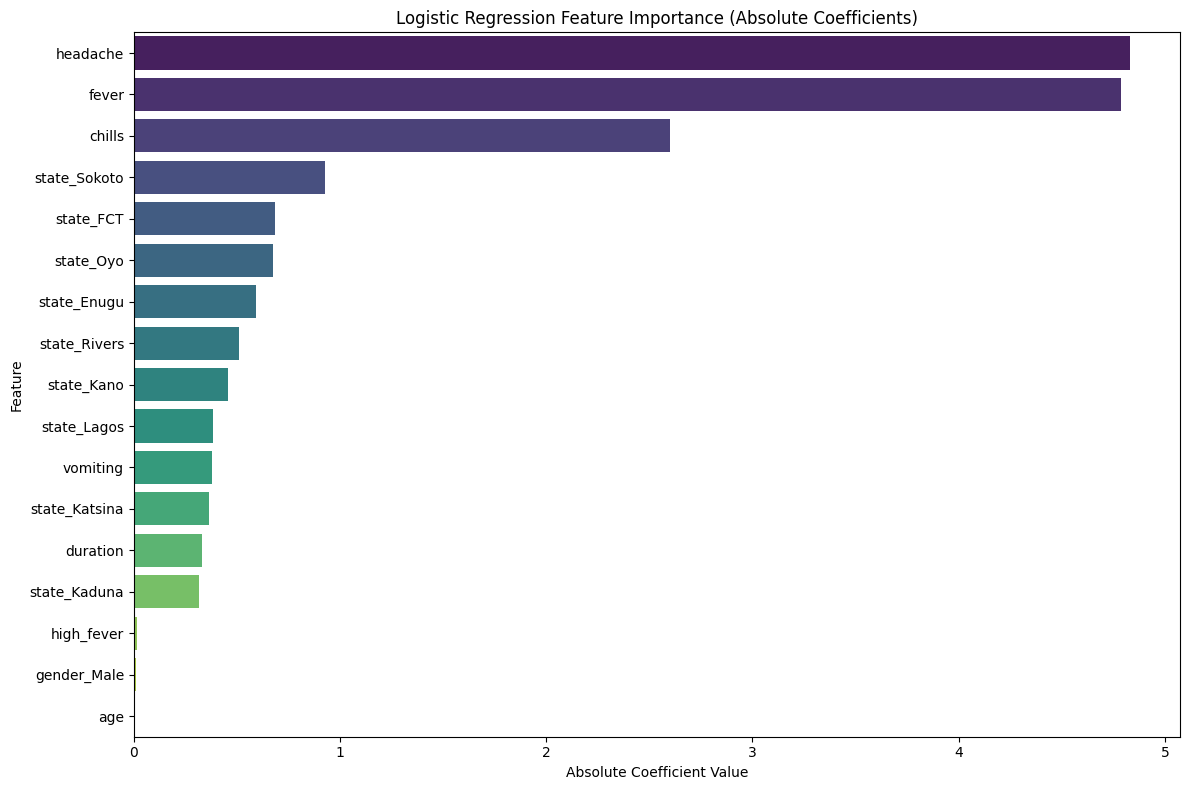

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Check if the best model is Logistic Regression and retrieve coefficients
if isinstance(best_model, LogisticRegression):
    # Get coefficients from the trained Logistic Regression model
    # Use absolute values for importance as direction doesn't matter for magnitude of influence
    feature_importances = np.abs(best_model.coef_[0])

    # Get feature names from the training data
    # Ensure feature_names list is correctly aligned with coefficients
    feature_names_list = feature_names # Already loaded from 'feature_names.pkl'

    # Create a DataFrame for better visualization
    importance_df = pd.DataFrame({'Feature': feature_names_list, 'Importance': feature_importances})

    # Sort the features by importance in descending order
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print("Feature Importance (Absolute Coefficients of Logistic Regression Model):")
    display(importance_df.head(10))

    # Create the bar plot
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
    plt.title('Logistic Regression Feature Importance (Absolute Coefficients)')
    plt.xlabel('Absolute Coefficient Value')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance for the selected model type is not directly available via coefficients.")
    print("Please check the model type if you were expecting a different feature importance method.")

### 3.3 Cross-Validation Check

In [79]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation using the best model and ROC AUC scoring
cv_scores_best_model = cross_val_score(best_model, X, y, cv=5, scoring='roc_auc')

print(f"Cross-validation ROC-AUC scores for the {best_model_name} model: {cv_scores_best_model}")
print(f"Mean cross-validation ROC-AUC for the {best_model_name} model: {cv_scores_best_model.mean():.2f}")
print(f"Standard deviation of cross-validation ROC-AUC for the {best_model_name} model: {cv_scores_best_model.std():.2f}")

# Generalize the comparison with test set performance (if relevant and available)
# For the best model, we already have its test ROC-AUC stored in model_performance
test_roc_auc_best_model = model_performance[best_model_name]['roc_auc']

if cv_scores_best_model.mean() < test_roc_auc_best_model:
    print(f"\nNote: The mean cross-validation ROC-AUC is slightly lower than the test ROC-AUC ({test_roc_auc_best_model:.2f}), which can indicate that the model's performance is stable and not significantly overfitting. A small drop is expected with cross-validation as it evaluates the model on different subsets.")
elif cv_scores_best_model.mean() > test_roc_auc_best_model:
    print(f"\nNote: The mean cross-validation ROC-AUC ({cv_scores_best_model.mean():.2f}) is higher than the test ROC-AUC ({test_roc_auc_best_model:.2f}), indicating good generalization.")
else:
    print(f"\nNote: The mean cross-validation ROC-AUC ({cv_scores_best_model.mean():.2f}) is comparable to the test ROC-AUC ({test_roc_auc_best_model:.2f}), indicating good generalization.")

Cross-validation ROC-AUC scores for the Logistic Regression model: [0.99247405 0.99307958 0.98599378 0.99002057 0.98875126]
Mean cross-validation ROC-AUC for the Logistic Regression model: 0.99
Standard deviation of cross-validation ROC-AUC for the Logistic Regression model: 0.00

Note: The mean cross-validation ROC-AUC (0.99) is higher than the test ROC-AUC (0.99), indicating good generalization.


### 3.4 Test Set Classification Metrics

In [80]:
from sklearn.metrics import classification_report

# Get predictions for the best model
y_pred_best_model = best_model.predict(X_test)

print(f"Classification Report for the {best_model_name} on Test Set:")
print(classification_report(y_test, y_pred_best_model))

Classification Report for the Logistic Regression on Test Set:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       341
           1       0.93      0.76      0.84        67

    accuracy                           0.95       408
   macro avg       0.94      0.87      0.90       408
weighted avg       0.95      0.95      0.95       408



### 3.5 Receiver Operating Characteristic (ROC) Curve

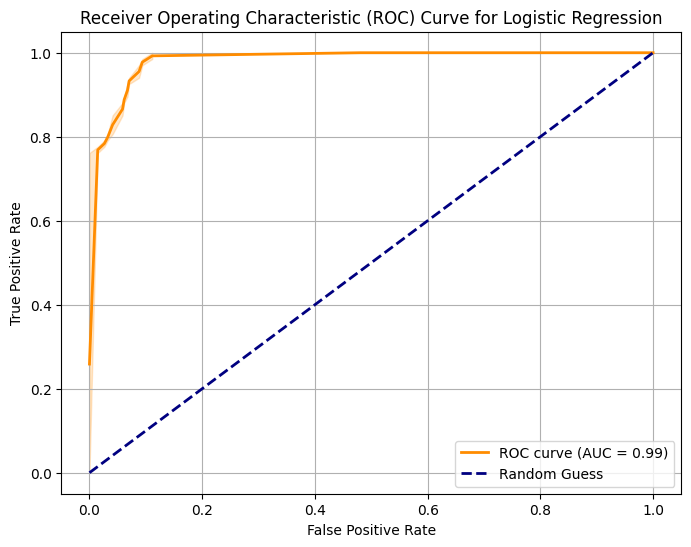

In [81]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (Malaria) using the best model
y_pred_proba_best_model = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best_model)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba_best_model)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr, y=tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
sns.lineplot(x=[0, 1], y=[0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for {best_model_name}')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 3.6 Confusion Matrix

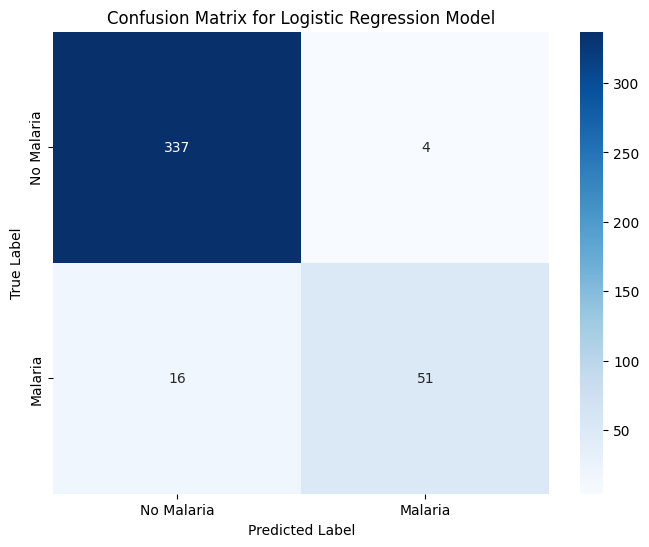

In [82]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for the best model
cm = confusion_matrix(y_test, y_pred_best_model)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Malaria', 'Malaria'],
            yticklabels=['No Malaria', 'Malaria'])
plt.title(f'Confusion Matrix for {best_model_name} Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 4. Urgency Level Assignment

Urgency levels are assigned based on the **Logistic Regression** model's prediction probabilities for 'Malaria'.

*   **Thresholds (example values):**
    *   **Low Urgency:** `Probability < 0.3`
    *   **Medium Urgency:** `0.3 <= Probability < 0.7`
    *   **High Urgency:** `Probability >= 0.7`

A crucial safety disclaimer is integrated to manage user expectations.

In [83]:
# Get prediction probabilities for the positive class (Malaria) using the best model
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test) # Assign predictions from the best model

In [84]:
def assign_urgency(probability):
    if probability < 0.3:
        return 'Low Risk', 'Monitor symptoms; consult a doctor if symptoms worsen.'
    elif 0.3 <= probability < 0.7:
        return 'Medium Risk', 'Consult a doctor within 24-48 hours.'
    else:  # probability >= 0.7
        return 'High Risk', 'Seek immediate medical attention.'

# Apply the urgency assignment to the prediction probabilities
# Unpack the tuple returned by assign_urgency into separate lists
urgency_recommendations = [assign_urgency(proba) for proba in y_pred_proba]
urgency_levels = [item[0] for item in urgency_recommendations]
recommendation_texts = [item[1] for item in urgency_recommendations]

# Display some sample predictions with their assigned urgency and probabilities
# Using y_test directly for actual diagnosis
sample_results = pd.DataFrame({
    'Actual Diagnosis': y_test.reset_index(drop=True),
    'Predicted Diagnosis': y_pred,
    'Malaria Probability': y_pred_proba,
    'Urgency Level': urgency_levels,
    'Recommendation': recommendation_texts
})
display(sample_results.head(10))

,Actual Diagnosis,Predicted Diagnosis,Malaria Probability,Urgency Level,Recommendation
0,0,0,0.080526,Low Risk,Monitor symptoms; consult a doctor if symptoms...
1,0,0,0.000252,Low Risk,Monitor symptoms; consult a doctor if symptoms...
2,0,0,0.000228,Low Risk,Monitor symptoms; consult a doctor if symptoms...
3,0,0,0.005710,Low Risk,Monitor symptoms; consult a doctor if symptoms...
4,0,0,0.000031,Low Risk,Monitor symptoms; consult a doctor if symptoms...
5,0,0,0.000028,Low Risk,Monitor symptoms; consult a doctor if symptoms...
6,0,0,0.006526,Low Risk,Monitor symptoms; consult a doctor if symptoms...
7,0,0,0.098367,Low Risk,Monitor symptoms; consult a doctor if symptoms...
8,0,0,0.004761,Low Risk,Monitor symptoms; consult a doctor if symptoms...
9,0,0,0.004064,Low Risk,Monitor symptoms; consult a doctor if symptoms...


In [85]:
# This cell is redundant and has been removed, as the correct assign_urgency function is in cell e73dc2c5.

In [86]:
# This cell is a duplicate and has been removed.

## 5. MVP Readiness: Prediction Function and Disclaimer

In [87]:
import joblib
import pandas as pd

# Load the best model and feature names
best_model = joblib.load('malaria_model.pkl')
feature_names = joblib.load('feature_names.pkl')

# Re-define the urgency assignment function for clarity and independence
def assign_urgency(probability):
    if probability < 0.3:
        return 'Low Risk', 'Monitor symptoms; consult a doctor if symptoms worsen.'
    elif 0.3 <= probability < 0.7:
        return 'Medium Risk', 'Consult a doctor within 24-48 hours.'
    else:  # probability >= 0.7
        return 'High Risk', 'Seek immediate medical attention.'

def predict_patient(
    age,
    gender,
    state,
    fever,
    high_fever,
    headache,
    chills,
    vomiting,
    duration
):
    # Create a DataFrame from the input
    input_data = pd.DataFrame({
        'age': [age],
        'gender': [gender],
        'state': [state],
        'fever': [fever],
        'high_fever': [high_fever],
        'headache': [headache],
        'chills': [chills],
        'vomiting': [vomiting],
        'duration': [duration]
    })

    # Apply the same preprocessing steps as the training data
    # Binary Encoding for 'Yes'/'No' columns
    binary_cols = ['fever', 'high_fever', 'headache', 'chills', 'vomiting']
    for col in binary_cols:
        input_data[col] = input_data[col].map({'Yes': 1, 'No': 0})

    # Ordinal Encoding for 'duration'
    duration_mapping = {'1-2 days': 1, '3-5 days': 2, '6-7 days': 3}
    input_data['duration'] = input_data['duration'].map(duration_mapping)

    # One-Hot Encoding for 'gender' and 'state'
    # Ensure consistent columns with training data
    input_data = pd.get_dummies(input_data, columns=['gender', 'state'], drop_first=True)

    # Reindex input_data to match the feature_names from training
    # Add missing columns with 0, and keep only the columns that were in training data
    for col in feature_names:
        if col not in input_data.columns:
            input_data[col] = 0
    input_data = input_data[feature_names] # Ensure order and presence of all features

    # Make prediction probability
    probability = best_model.predict_proba(input_data)[:, 1][0]
    prediction_class = best_model.predict(input_data)[0]

    # Assign urgency level and recommendation
    urgency, recommendation = assign_urgency(probability)

    # Convert prediction class back to 'Malaria' or 'No Malaria'
    prediction_label = 'Malaria' if prediction_class == 1 else 'No Malaria'

    return {
        "prediction": prediction_label,
        "probability": float(f"{probability:.2f}"),
        "urgency": urgency,
        "recommendation": recommendation
    }

# Example usage:
print("Example Patient 1 (High Risk):")
patient_1 = predict_patient(
    age=30,
    gender='Male',
    state='Kano',
    fever='Yes',
    high_fever='Yes',
    headache='Yes',
    chills='Yes',
    vomiting='Yes',
    duration='3-5 days'
)
display(patient_1)

print("\nExample Patient 2 (Low Risk):")
patient_2 = predict_patient(
    age=25,
    gender='Female',
    state='Lagos',
    fever='No',
    high_fever='No',
    headache='No',
    chills='No',
    vomiting='No',
    duration='1-2 days'
)
display(patient_2)

Example Patient 1 (High Risk):


{'prediction': 'Malaria',
 'probability': 0.91,
 'urgency': 'High Risk',
 'recommendation': 'Seek immediate medical attention.'}


Example Patient 2 (Low Risk):


{'prediction': 'No Malaria',
 'probability': 0.0,
 'urgency': 'Low Risk',
 'recommendation': 'Monitor symptoms; consult a doctor if symptoms worsen.'}

### Sample Prediction with `predict_patient` Function

In [88]:
print('\nExample Patient 3 (Medium Risk):')
patient_3 = predict_patient(
    age=45,
    gender='Female',
    state='Oyo',
    fever='Yes',
    high_fever='No',
    headache='Yes',
    chills='No',
    vomiting='No',
    duration='1-2 days'
)
display(patient_3)


Example Patient 3 (Medium Risk):


{'prediction': 'Malaria',
 'probability': 0.56,
 'urgency': 'Medium Risk',
 'recommendation': 'Consult a doctor within 24-48 hours.'}

### Top 10 Most Influential Features

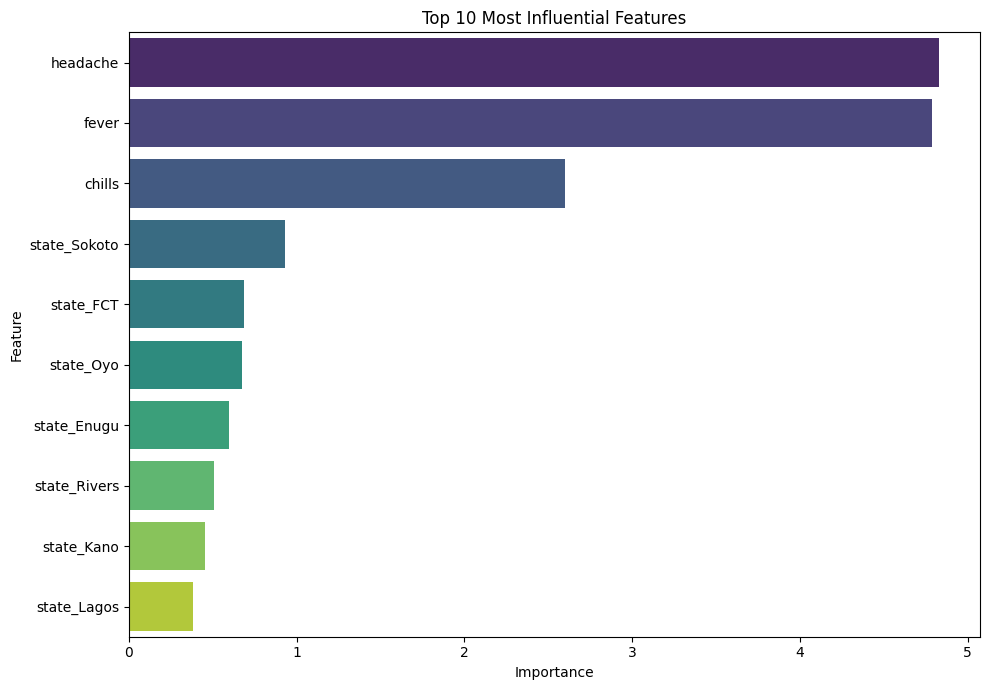

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top 10 most important features
top_10_features = importance_df.head(10)

# Create the bar plot for the top 10 features
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Most Influential Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()